In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv('lr.csv')

In [7]:
df.head()

,X,Y
0,1,3.888889
1,2,4.555556
2,3,5.222222
3,4,5.888889
4,5,6.555556


In [9]:
x=df.drop('Y',axis=1)
y=df['Y']

In [10]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x,y)

LinearRegression()

In [12]:
from sklearn.metrics import mean_squared_error, r2_score
mean_squared_error(y, model.predict(x))

262.22980714499374

In [22]:
x=np.random.rand(300,1)*10
y=2.5*x+2+np.random.rand(300,1)*2

In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [24]:
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [25]:
from sklearn.metrics import mean_squared_error, r2_score
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.3311289960413066
R2 Score: 0.9934529782394798


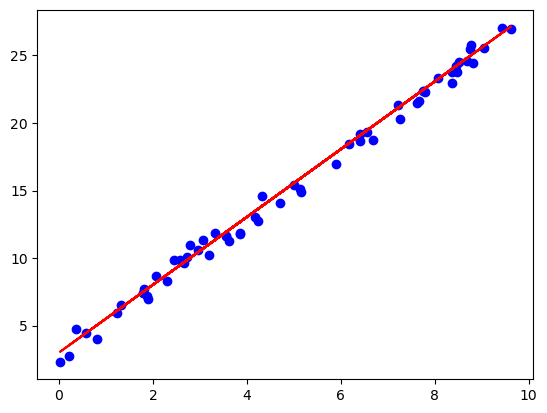

In [28]:
plt.scatter(x_test, y_test, color='blue')
plt.plot(x_test, model.predict(x_test), color='red')

In [30]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)
model = LinearRegression()
model.fit(x_train_poly, y_train)
y_pred_poly = model.predict(x_test_poly)
print("MSE (Polynomial):", mean_squared_error(y_test, y_pred_poly))
print("R2 Score (Polynomial):", r2_score(y_test, y_pred_poly))

MSE (Polynomial): 0.34273208768393065
R2 Score (Polynomial): 0.9932235640402348


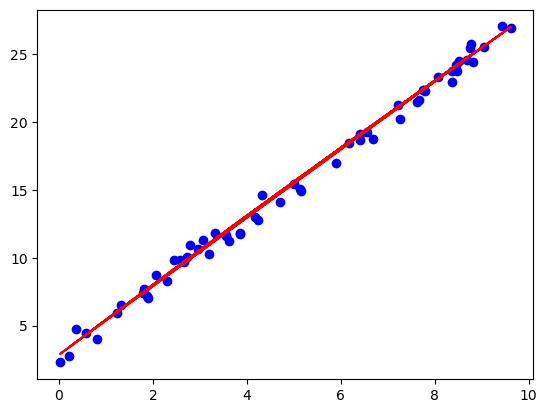

In [37]:
plt.scatter(x_test,y_test, color='blue')
plt.plot(x_test,y_pred_poly,color='red')

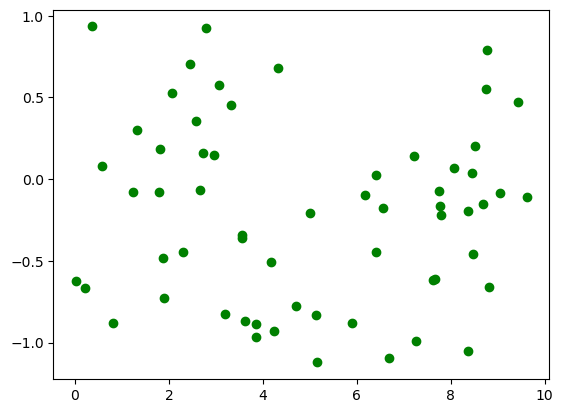

In [38]:
y_=y_test-y_pred_poly
plt.scatter(x_test,y_, color='green')

In [39]:
from sklearn.datasets import load_iris

In [40]:
x,y=load_iris(return_X_y=True)

In [46]:
c=x.columns

In [47]:
x=pd.DataFrame(x,columns=c)

In [48]:
x.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [52]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2)

In [53]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=3)
model.fit(xtrain,ytrain)
ypred=model.predict(xtest)
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(ytest,ypred)
cm

array([[10,  0,  0],
       [ 0, 11,  0],
       [ 0,  0,  9]], dtype=int64)

<Axes: >

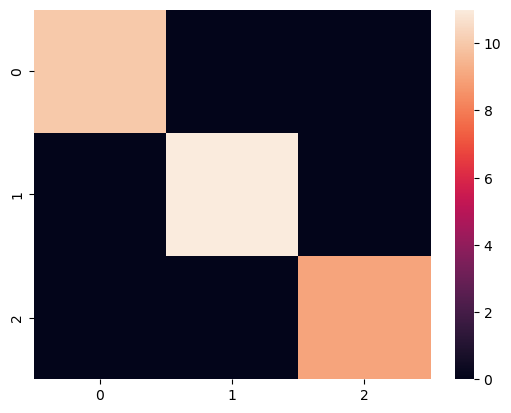

In [54]:
sns.heatmap(cm)

In [55]:
x=np.random.rand(300,1)*10
y=3*x+2+np.random.rand(300,1)*2

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(x_test)
from sklearn.metrics import mean_squared_error, r2_score
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.400427101733005
R2 Score: 0.9950577208584858


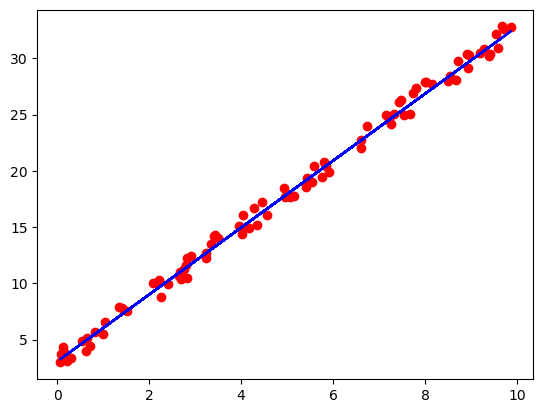

In [60]:
plt.scatter(x_test,y_test,color='red')
plt.plot(x_test,y_pred,color='blue')

MSE (Polynomial): 0.4017221660567423
R2 Score (Polynomial): 0.995041736502366


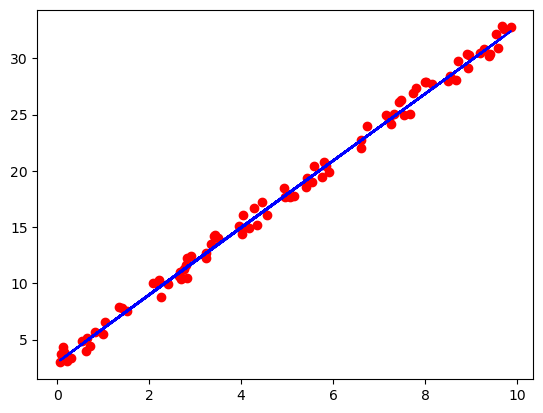

In [61]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)
model = LinearRegression()
model.fit(x_train_poly, y_train)
y_pred_poly = model.predict(x_test_poly)
print("MSE (Polynomial):", mean_squared_error(y_test, y_pred_poly)) 
print("R2 Score (Polynomial):", r2_score(y_test, y_pred_poly))
plt.scatter(x_test,y_test,color='red')
plt.plot(x_test,y_pred_poly,color='blue')

In [63]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
ridge_model=Ridge(alpha=1.0)
ridge_model.fit(x_train,y_train)    
lasso_model=Lasso(alpha=0.1)
lasso_model.fit(x_train,y_train)
y_ridge_pred=ridge_model.predict(x_test)
y_lasso_pred=lasso_model.predict(x_test)
print("Ridge MSE:", mean_squared_error(y_test, y_ridge_pred))
print("Ridge R2 Score:", r2_score(y_test, y_ridge_pred))
print("Lasso MSE:", mean_squared_error(y_test, y_lasso_pred))
print("Lasso R2 Score:", r2_score(y_test, y_lasso_pred))


Ridge MSE: 0.4009924306365371
Ridge R2 Score: 0.99505074327571
Lasso MSE: 0.4057368727565291
Lasso R2 Score: 0.9949921849083411


In [65]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

[Text(0.5, 0.9, 'x[2] <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 39, 41]'),
 Text(0.4230769230769231, 0.7, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.46153846153846156, 0.8, 'True  '),
 Text(0.5769230769230769, 0.7, 'x[3] <= 1.75\ngini = 0.5\nsamples = 80\nvalue = [0, 39, 41]'),
 Text(0.5384615384615384, 0.8, '  False'),
 Text(0.3076923076923077, 0.5, 'x[2] <= 4.95\ngini = 0.172\nsamples = 42\nvalue = [0, 38, 4]'),
 Text(0.15384615384615385, 0.3, 'x[3] <= 1.65\ngini = 0.053\nsamples = 37\nvalue = [0, 36, 1]'),
 Text(0.07692307692307693, 0.1, 'gini = 0.0\nsamples = 36\nvalue = [0, 36, 0]'),
 Text(0.23076923076923078, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.46153846153846156, 0.3, 'x[3] <= 1.55\ngini = 0.48\nsamples = 5\nvalue = [0, 2, 3]'),
 Text(0.38461538461538464, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.5384615384615384, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2, 0]'),
 Text(0.8461538461538461, 0.5, 'x[2] <= 4.85\ngini 

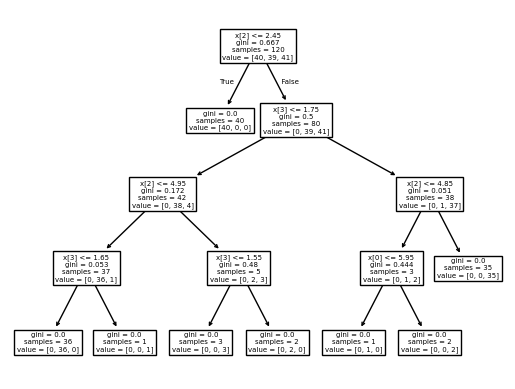

In [66]:
gini=DecisionTreeClassifier(criterion='gini')
entropy=DecisionTreeClassifier(criterion='entropy')
gini.fit(xtrain,ytrain)
entropy.fit(xtrain,ytrain)
plot_tree(gini)